<font size=6>**Operational Risk with Compound Poisson**</font>
___

This notebook applies the *Advanced Measurement Approach* to determining Operational Risk Regulatory Capital.

The model for the losses in a compound Poisson distribution where the number of losses $N$ follows a poisson distribution and the severity of the losses $X_i$ follows a LogNormal distribution. We then have that the total amount of losses sustained over a year is the random quantity

$$S_N = \sum_{i=1}^N X_i, \qquad N \sim \mathrm{Poi}(\lambda), \qquad X_i \sim \mathrm{LogNorm}(\mu, \sigma^2)$$

As you are free to use LLM to generate code, you have to **add comments for each (important) step of code**.

$\blacktriangleright$ The grade of the notebook will be a function of the code running without errors and of the quality of the comments.

In [1]:
import math
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

The notebook should contain:
1. A function which plots the probability mass function of the Poisson distribution.
2. A function which plots the probability density function of the LogNormal distribution.
3. A function which simulate losses with the Monte-Carlo method, which plots the histogram of the yearly sum of losses $S_N$, and which prints the first four sample moments.
4. A function which returns the empirical VaR with the empirical ES at confidence level $\alpha$ where the sample is the input. Print the 90%, 95%, 99%, 99.5% VaR.
5. A function which plots the histogram of the losses $S_N$ with vertical lines indicating the mean and 90%, 95%, 99%, 99.5% VaR levels (possibly also the ES at these confidence levels).

The parameters of the distribution should be
- for the [Poisson distribution](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.poisson.html): $\lambda = 5$,
- for the [LogNormal distribution](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.lognorm.html): $s$ and $\mathrm{scale}$ as computed below. The unit is million EUR.

In [2]:
# select the first two moments of a LogNormal distribution
mean = 1
variance = 1.5 ** 2

# parameters of LogNorm(mu, sigma^2)
sigma2 = math.log(1 + variance/mean**2)
mu = math.log(mean) - 0.5*sigma2

# parameters of the scipy.stats function
s = sigma2 ** 0.5
scale = math.exp(mu)

The parameters of the distributions or the distributions themselves can be considered as global parameters in this notebook and can be excluded from the functions' inputs.

In [3]:
_default_rng = np.random.default_rng(seed=42)

def plot_poisson(n_max):  # Define the function "plot_poisson" with variable "n_max"
    n = np.arange(n_max + 1)  # Create an array of integers from 0 to n_max inclusive (0,1,2,3,4,5 if n_max=5)
    pmf = stats.poisson.pmf(n, mu=5)  # Compute the Poisson probability mass function P(X=n) for λ=5

    plt.figure(figsize=(8, 4))  # Create a new figure window with dimensions 8x4 inches
    plt.bar(n, pmf, color='skyblue', edgecolor='black')  # Draw a bar chart of Poisson probabilities
    plt.xlabel('Number of Loss Events (n)')  # Label the x-axis
    plt.ylabel('Probability')  # Label the y-axis
    plt.title(f'Poisson PMF (λ=5)')  # Add a title indicating λ=5
    
    # Display each probability value rounded to 3 decimals above its corresponding bar
    for x, y in zip(n, pmf):  # Pair each x value (n) with its probability P(X=n)
        # Place text slightly above the bar (y + 0.005) to avoid overlap
        # f"{y:.3f}" formats the number to 3 decimal places
        plt.text(x, y + 0.005, f"{y:.3f}", ha='center', fontsize=8)

    plt.ylim(0, pmf.max() * 1.2)  # Extend the y-axis 20% higher than the tallest bar
    plt.grid(axis='y', linestyle='--', alpha=0.4)  # Add light dashed horizontal gridlines
    plt.tight_layout()  # Adjust spacing to prevent label overlap
    plt.show()  # Render the plot

# The purpose of the plot_poisson(n_max) function is to visualize the Poisson probability distribution for a random variable representing the number of events occurring within a fixed time or space interval.
# The function assumes a Poisson distribution with a mean (λ) of 5 and displays the probability mass function (PMF) for all possible event counts from 0 up to n_max. 
# It creates a bar chart where each bar represents the probability of observing exactly n events.


def plot_lognormal(x_max):  # Define a function "plot_lognormal" taking the upper x limit as argument
    # Generate 1000 evenly spaced x values between 0.0001 and x_max
    # (We avoid 0 because the lognormal PDF is undefined at x=0)
    x = np.linspace(1e-4, x_max, 1000)

    pdf = stats.lognorm.pdf(x, s, scale=scale)  # Compute the lognormal PDF f(x) for each x
    # Parameters: s = σ, scale = e^μ (from the upper code)

    plt.figure(figsize=(8, 4))  # Create a new figure with size 8x4 inches
    plt.plot(x, pdf, linewidth=1.5)  # Plot the continuous lognormal density curve
    plt.xlabel('Loss Severity (Million EUR)')  # Label the x-axis
    plt.ylabel('Density')  # Label the y-axis
    plt.title(f'LogNormal PDF (mean={mean}, variance={variance})')  # Show title with mean and variance
    plt.grid(linestyle='--', alpha=0.4)  # Add dashed gridlines for readability
    plt.tight_layout()  # Optimize layout spacing
    plt.show()  # Display the plot

# The purpose of the plot_lognormal(x_max) function is to visualize the probability density function (PDF) of a lognormal distribution.
# This function generates a smooth curve showing how probable different loss amounts are under a lognormal model defined by parameters s (σ) and scale (equal to eμ). 
# The x-axis represents the possible loss sizes, while the y-axis shows their probability density.


def simulate_losses(sample_size):  # Define the function simulate_losses with parameter sample_size
    # Generate a Poisson-distributed number of events N for each simulated year
    # λ = 5 (mean and variance = 5)
    # size = sample_size : number of simulated years
    N = stats.poisson.rvs(mu=5, size=sample_size, random_state=_default_rng)

    # For each simulated year (each N), generate N independent lognormal losses and sum them
    # If N=0 (no events), total loss = 0
    S = np.array([
        stats.lognorm.rvs(s, scale=scale, size=n, random_state=_default_rng).sum() if n > 0 else 0
        for n in N
    ])

    plt.figure(figsize=(10, 5))  # Create a 10x5 inch figure
    plt.hist(S, bins=60, alpha=0.75, edgecolor='black')  # Plot histogram of total yearly losses
    plt.xlabel('Yearly Loss (Million EUR)')  # Label x-axis
    plt.ylabel('Frequency')  # Label y-axis
    plt.title(f'Histogram of Yearly Losses S_N (sample_size={sample_size})')  # Dynamic title
    plt.grid(axis='y', linestyle='--', alpha=0.4)  # Add horizontal gridlines
    plt.tight_layout()  # Adjust layout
    plt.show()  # Display histogram

    # Print descriptive statistics of the simulated yearly losses
    print(f"Sample mean:     {S.mean():.6f} Million EUR")  # Sample mean
    print(f"Sample variance: {S.var(ddof=0):.6f}")  # Sample variance
    print(f"Sample skewness: {stats.skew(S):.6f}")  # Skewness
    print(f"Sample kurtosis: {stats.kurtosis(S):.6f} (excess)")  # Excess kurtosis
    return S  # Return simulated losses

# The purpose of the simulate_losses(sample_size) function is to simulate annual total losses in a risk model where the number of loss events follows a Poisson distribution and each individual loss amount follows a lognormal distribution. 
# This type of simulation is commonly used in operational risk modeling and insurance analytics to estimate aggregate losses over time.


def empirical_VaR_ES(sample, alpha):  # Define function to compute empirical Value-at-Risk
    if len(sample) == 0:  # Ensure sample is not empty
        raise ValueError("Empty sample")  # Raise an error if no data provided

    # Compute the empirical Value-at-Risk
    # Sort the sample externally before passing if needed
    # The index corresponds to the α-quantile ( α=0.95 : 95th percentile)
    return sample[max(0, int(np.ceil(alpha * len(sample))) - 1)]

# The purpose of the empirical_VaR_ES(sample, alpha) function is to compute the empirical Value-at-Risk (VaR) at a given confidence level α from a sample of simulated or observed losses.
# In risk management, Value-at-Risk (VaR) represents the loss threshold that will not be exceeded with probability α. 
# For example, a 95% VaR indicates the level of loss that is exceeded only 5% of the time.


def plot_VaR_ES(sample):  # Define a function to visualize empirical VaR and ES on a histogram
    sample = np.asarray(sample)  # Convert input to NumPy array for safety
    if sample.size == 0: return  # Exit if the sample is empty

    mean_val = sample.mean()  # Compute sample mean (expected annual loss)
    levels = [0.9, 0.95, 0.99, 0.995]  # Confidence levels for VaR and ES
    sorted_sample = np.sort(sample)  # Sort sample in ascending order
    VaR_lines = {cl: empirical_VaR_ES(sorted_sample, cl) for cl in levels}  # Compute empirical VaRs

    plt.figure(figsize=(10, 5))  # Create figure (10x5 inches)
    plt.hist(sample, bins=60, alpha=0.75, edgecolor='black')  # Plot histogram
    plt.axvline(mean_val, color='black', linestyle='-', linewidth=1.5, label=f"Mean: {mean_val:.3f}")  # Add mean line

    colors = ['red', 'orange', 'green', 'purple']  # Color palette for VaR/ES markers
    for i, cl in enumerate(levels):  # Iterate through confidence levels
        v = VaR_lines[cl]  # Corresponding VaR value
        # Plot VaR as a dashed line
        plt.axvline(v, color=colors[i % len(colors)], linestyle='--', linewidth=1.5, label=f"VaR {cl*100:.1f}%: {v:.3f}")

        tail = sample[sample >= v]  # Right-tail losses beyond the VaR threshold
        es = tail.mean() if tail.size > 0 else v  # Compute Expected Shortfall (mean of tail), fallback to VaR if empty

        # Plot ES as a dotted line (same color as VaR or cycled)
        plt.axvline(es, color=colors[(i + len(levels)) % len(colors)], linestyle=':', linewidth=2, label=f"ES {cl*100:.1f}%: {es:.3f}")

    plt.xlabel('Yearly Loss (Million EUR)')  # Label x-axis
    plt.ylabel('Frequency')  # Label y-axis
    plt.title('Histogram of Yearly Losses S_N with VaR/ES Levels')  # Add title
    plt.legend()  # Display legend
    plt.grid(axis='y', linestyle='--', alpha=0.4)  # Add horizontal gridlines
    plt.tight_layout()  # Optimize layout
    plt.show()  # Render plot

# The purpose of the plot_VaR_ES(sample) function is to visualize risk measures, Value-at-Risk (VaR) and Expected Shortfall (ES), on a histogram of simulated or observed losses. 
# It provides an intuitive, graphical way to understand the tail behavior of the loss distribution and to compare different confidence levels (90%, 95%, 99%, 99.5%).


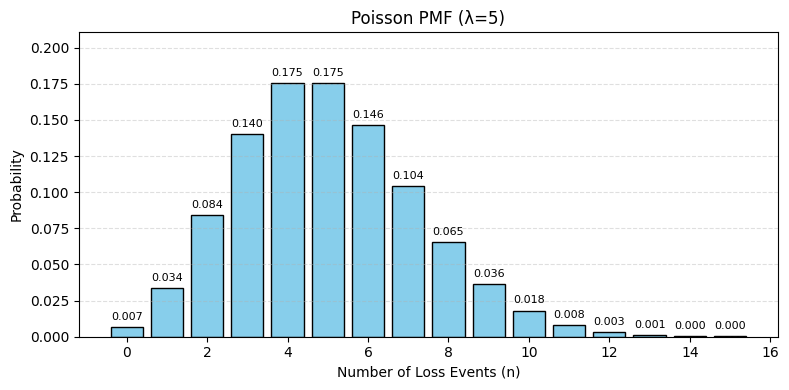

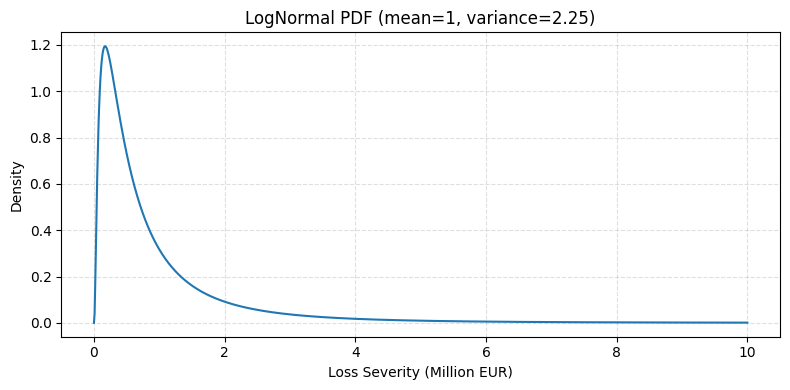

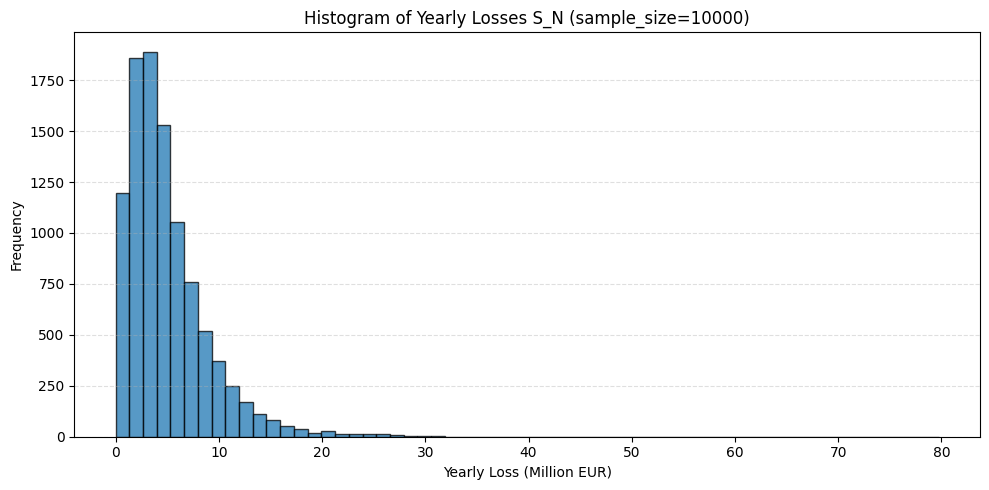

Sample mean:     5.013707 Million EUR
Sample variance: 17.129067
Sample skewness: 2.758263
Sample kurtosis: 20.022917 (excess)


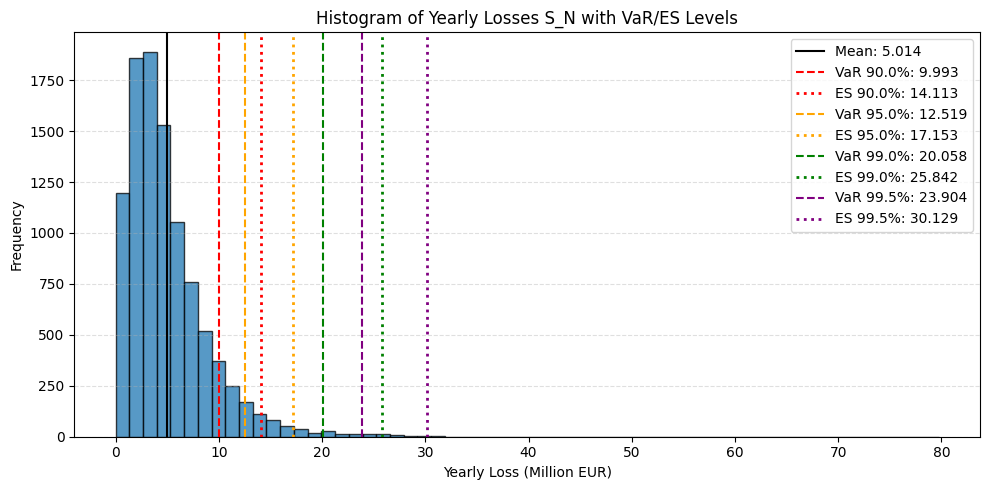

In [4]:
# Display the PMF of the Poisson distribution for n = 0..15 with lambda = 5
plot_poisson(15)

# Display the LogNormal probability density function for x up to 10 (million EUR)
plot_lognormal(x_max=10)

# Simulate 10,000 years of losses and display histogram + moments
S = simulate_losses(sample_size=10000)

# Plot the histogram of losses with lines for mean, VaR, and ES
plot_VaR_ES(S)